In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [3]:
df = pd.read_sql("SELECT * FROM NearsestSample", conn)

df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)].reset_index(drop=True)

In [4]:
df = df.drop(columns=["id","x7","SpatialDim"], errors="ignore")
df.columns = [
    'cardiovascular_diseases',
    'air_pollution',
    'alcohol_consumption',
    'BMI',
    'cholesterol',
    'diabetes',
    'glucose',
    'physical_activities',
    'tobacco',
    'time'
]

In [5]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  float64
 1   air_pollution            10890 non-null  float64
 2   alcohol_consumption      10735 non-null  float64
 3   BMI                      10956 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   time                     10956 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 856.1 KB


In [6]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution               66
alcohol_consumption        221
BMI                          0
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
time                         0
dtype: int64

In [7]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10956.0,55.593244,35.512469,8.701838,32.768090,40.400000,62.100000,1.375000e+02
air_pollution,10956.0,8290.686407,319532.735705,0.000000,51.066000,193.716500,582.009500,2.509519e+07
alcohol_consumption,10956.0,41.429338,19.257525,2.680089,26.664454,40.181983,52.406960,9.921560e+01
BMI,10956.0,22.424149,17.616987,0.238787,7.450371,22.200000,27.200000,9.247079e+01
cholesterol,10956.0,2.903514,1.426160,0.800000,1.300000,3.300000,4.000000,5.300000e+00
diabetes,10956.0,16.683322,16.735358,2.800000,5.694480,8.000000,20.600000,8.310288e+01
glucose,10956.0,8.657804,4.239293,2.100000,5.900000,8.000000,9.800000,2.980000e+01
physical_activities,10956.0,26.063816,11.766169,3.335438,17.580842,23.772923,32.636906,6.920515e+01
tobacco,10956.0,23.755696,14.737694,0.000000,12.475000,23.000000,32.800000,7.700000e+01
time,10956.0,2012.500000,1.707903,2010.000000,2011.000000,2012.500000,2014.000000,2.015000e+03


<Axes: xlabel='air_pollution', ylabel='Count'>

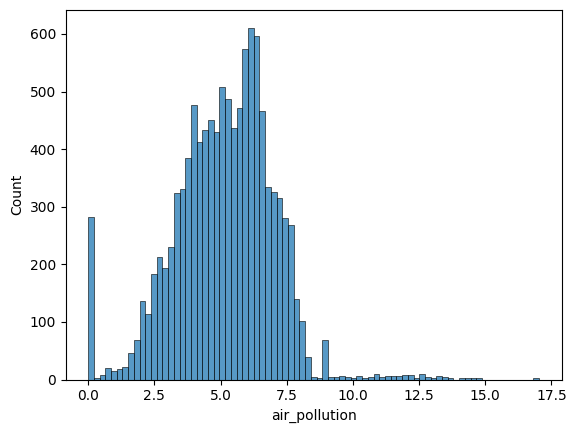

In [9]:
df['air_pollution'] = np.log1p(df['air_pollution'])
sns.histplot(df['air_pollution'])

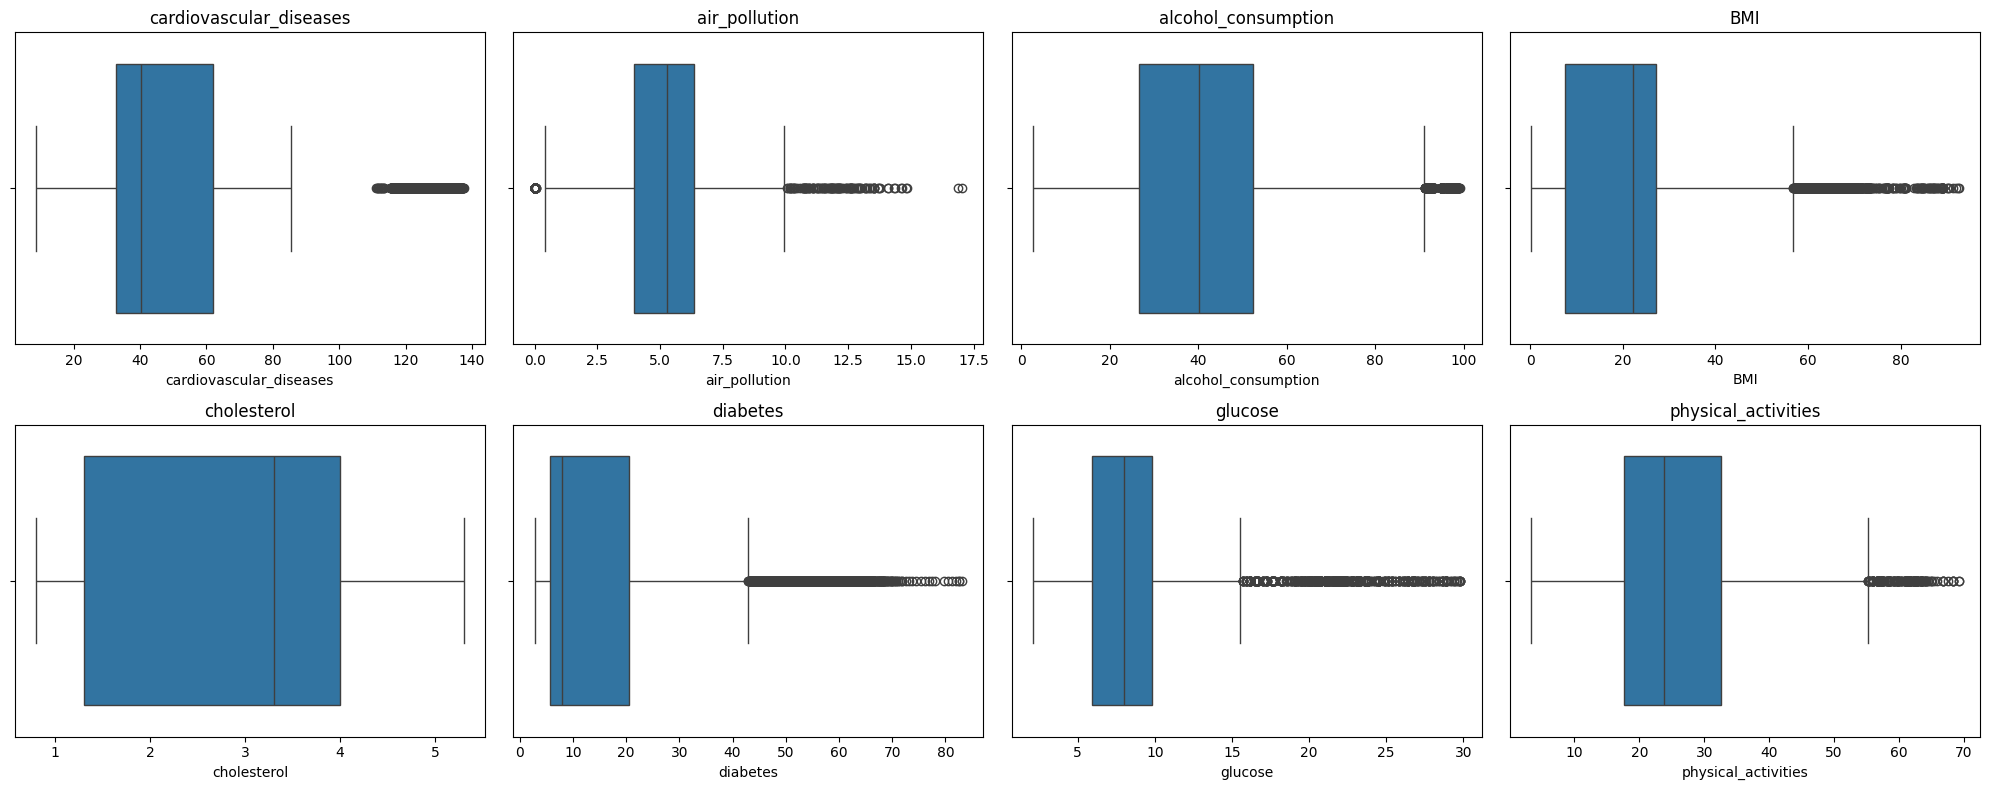

In [10]:
cols = df.columns[:-1]

plt.figure(figsize=(20,8))

for i, col in enumerate(cols[:8]):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
df_original = df.copy()

df = df_original.copy()
mask = pd.Series(True, index=df.index)

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask]
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10516.0,55.572949,35.542217,8.701838,32.563800,40.400000,62.400000,137.500000
air_pollution,10516.0,5.207420,1.771220,0.000000,4.009980,5.321553,6.376214,13.545595
alcohol_consumption,10516.0,41.115960,19.344295,2.680089,26.329860,39.558602,52.089425,99.215604
BMI,10516.0,21.950324,16.729627,0.278393,7.638558,22.093331,27.000000,86.219949
cholesterol,10516.0,2.901645,1.422474,0.800000,1.300000,3.300000,4.000000,5.300000
diabetes,10516.0,15.989212,16.113572,2.800000,5.638325,7.800000,17.900000,65.311879
glucose,10516.0,8.173089,3.239386,2.100000,5.900000,8.000000,9.600000,21.500000
physical_activities,10516.0,25.783852,11.748494,3.335438,17.459205,23.452808,32.150654,69.205147
tobacco,10516.0,23.342716,14.653492,0.000000,12.000000,22.700000,32.500000,77.000000
time,10516.0,2012.483739,1.708200,2010.000000,2011.000000,2012.000000,2014.000000,2015.000000


In [12]:
df_model = df.copy()

y = df_model['cardiovascular_diseases']

X = df_model.drop(columns=['cardiovascular_diseases','time'])

feature_names = X.columns

In [13]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [15]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X_train, X_test, y_train, y_test):

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [16]:
coef, inter = run_for_linear(X_train, X_test, y_train, y_test)

MSE: 1044.7615297514415
R2: 0.17958377526877167
Coefficients: [ 2.19945418 -2.07592666  4.49913773 14.58338672 -3.05196749  0.81452408
 -0.89665972 -0.7241319 ]
Intercept: 55.544725328720865


In [17]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

In [18]:
importance = np.abs(coef)
importance = importance / importance.sum()

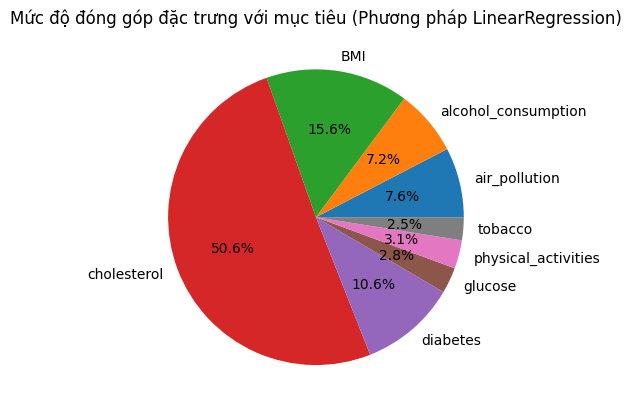

In [19]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu

plt.figure()
plt.pie(importance, labels=feature_names, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [20]:
def run_for_random_forest(X_train, X_test, y_train, y_test):

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [21]:
impor = run_for_random_forest(X_train, X_test, y_train, y_test)

MSE: 283.6509367555466
R2: 0.7772584230491084
Feature Importances: [2.35527304e-04 4.61696849e-03 5.66460929e-01 3.19178371e-01
 7.60378806e-02 3.25485943e-02 4.78079732e-04 4.43649083e-04]


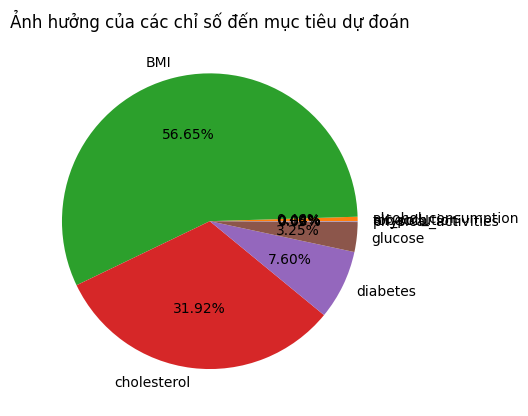

In [22]:
plt.figure()
plt.pie(impor.tolist(), labels=feature_names, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [23]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

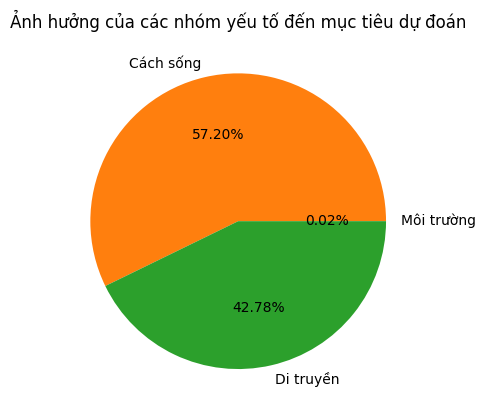

In [24]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [25]:
from xgboost import XGBRegressor


In [26]:
def run_for_xgboost(X_train, X_test, y_train, y_test):

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    return model.feature_importances_

In [27]:
xgb_importance = run_for_xgboost(X_train, X_test, y_train, y_test)

MSE: 202.66428685476174
R2: 0.8408545257703093


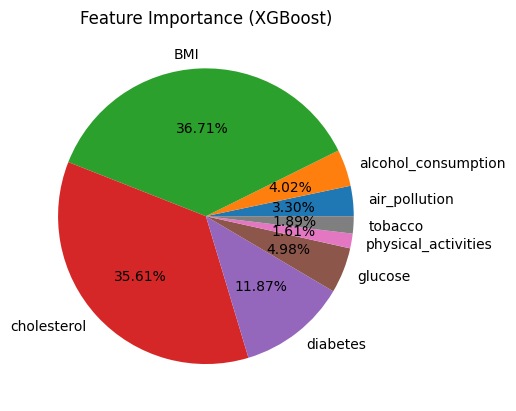

In [28]:
plt.figure()

plt.pie(
    xgb_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)

plt.title("Feature Importance (XGBoost)")
plt.show()

In [32]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, xgb_importance.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

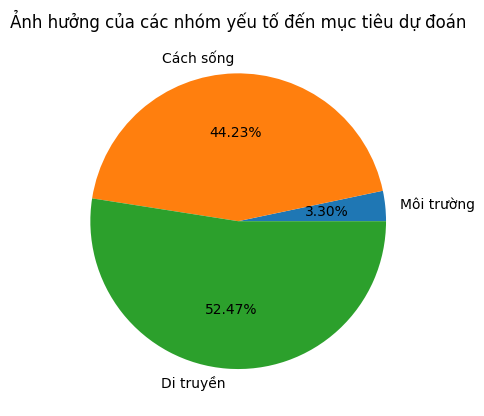

In [33]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [29]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
0,134.9,-1.001935,-0.894135,0.248055,1.475214,-0.545480,-0.084307,-0.091781,0.324667,2010
1,136.1,-0.657414,-1.537598,0.277944,1.404911,2.370126,0.070051,-0.022825,-1.088032,2015
2,135.9,-0.637445,-1.534259,0.271966,1.404911,-0.514449,0.070051,-0.038924,-1.088032,2014
3,135.6,0.548722,-0.950272,0.265988,1.475214,-0.520655,0.039179,-0.053906,-1.088032,2013
4,135.2,0.634738,-1.505838,0.254033,1.475214,-0.539274,-0.053435,-0.676102,0.324667,2011


In [30]:
features_all = features + ['cardiovascular_diseases']

corr_matrix = df_scaled[features_all].corr()

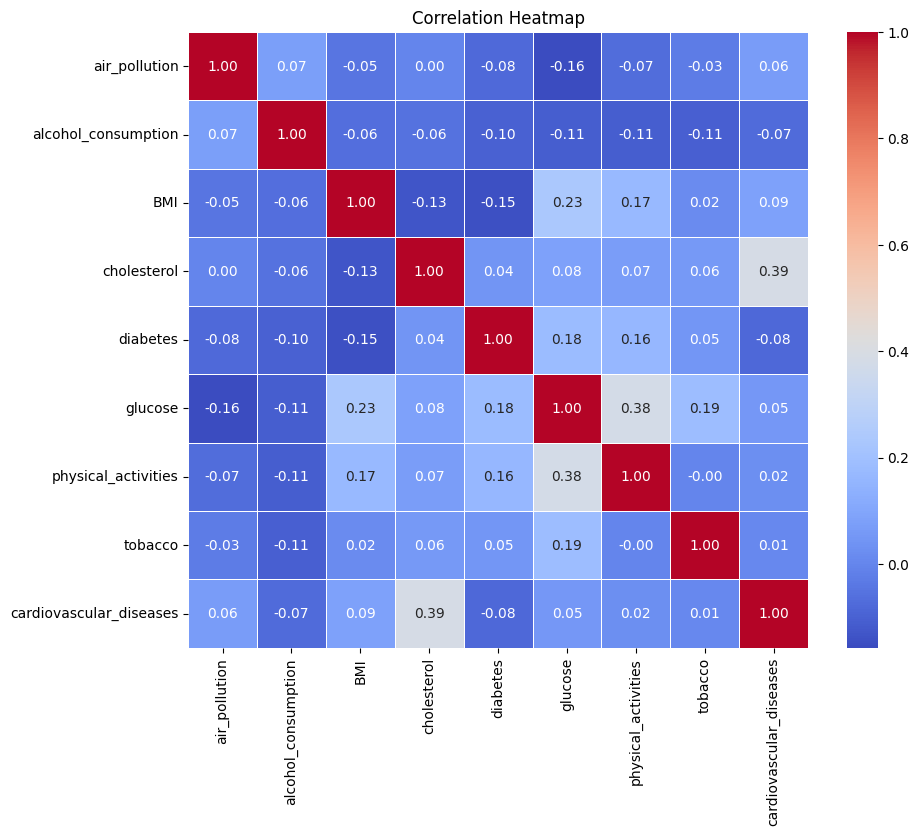

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()